# Semantic Drift in CJEU Case Law (1990--2025)

Results from diachronic word2vec embeddings trained on EU Court of Justice judgments.  
**Pipeline**: preprocess &rarr; phrase detection &rarr; Word2Vec (5-year sliding windows) &rarr; Procrustes alignment &rarr; drift metrics.

> **Note**: These results are from the prototype run (dim=30, 3 epochs, 4 workers).  
> Replace the parquet files with the server output for production-quality results.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

# Load metrics
shifts = pd.read_parquet("../data/results/metrics/shifts.parquet").dropna(subset=["combined_shift"])
dispersion = pd.read_parquet("../data/results/metrics/dispersion.parquet")
coherence = pd.read_parquet("../data/results/metrics/coherence.parquet")

def window_midpoint(label: str) -> float:
    """Convert 'w1990_1994' to 1992.0."""
    parts = label.lstrip("w").split("_")
    return (int(parts[0]) + int(parts[1])) / 2

print(f"Shifts:     {shifts.shape[0]:,} rows, {shifts['word'].nunique():,} words, {shifts[['t1','t2']].drop_duplicates().shape[0]} time pairs")
print(f"Dispersion: {dispersion.shape[0]:,} rows")
print(f"Coherence:  {coherence.shape[0]:,} rows, {coherence['domain'].nunique()} domains")

Shifts:     203,812 rows, 9,738 words, 31 time pairs
Dispersion: 311,616 rows
Coherence:  320 rows, 10 domains


---
## 1. Global drift landscape

Which words shifted the most (and least) across the full 1990--2025 span?

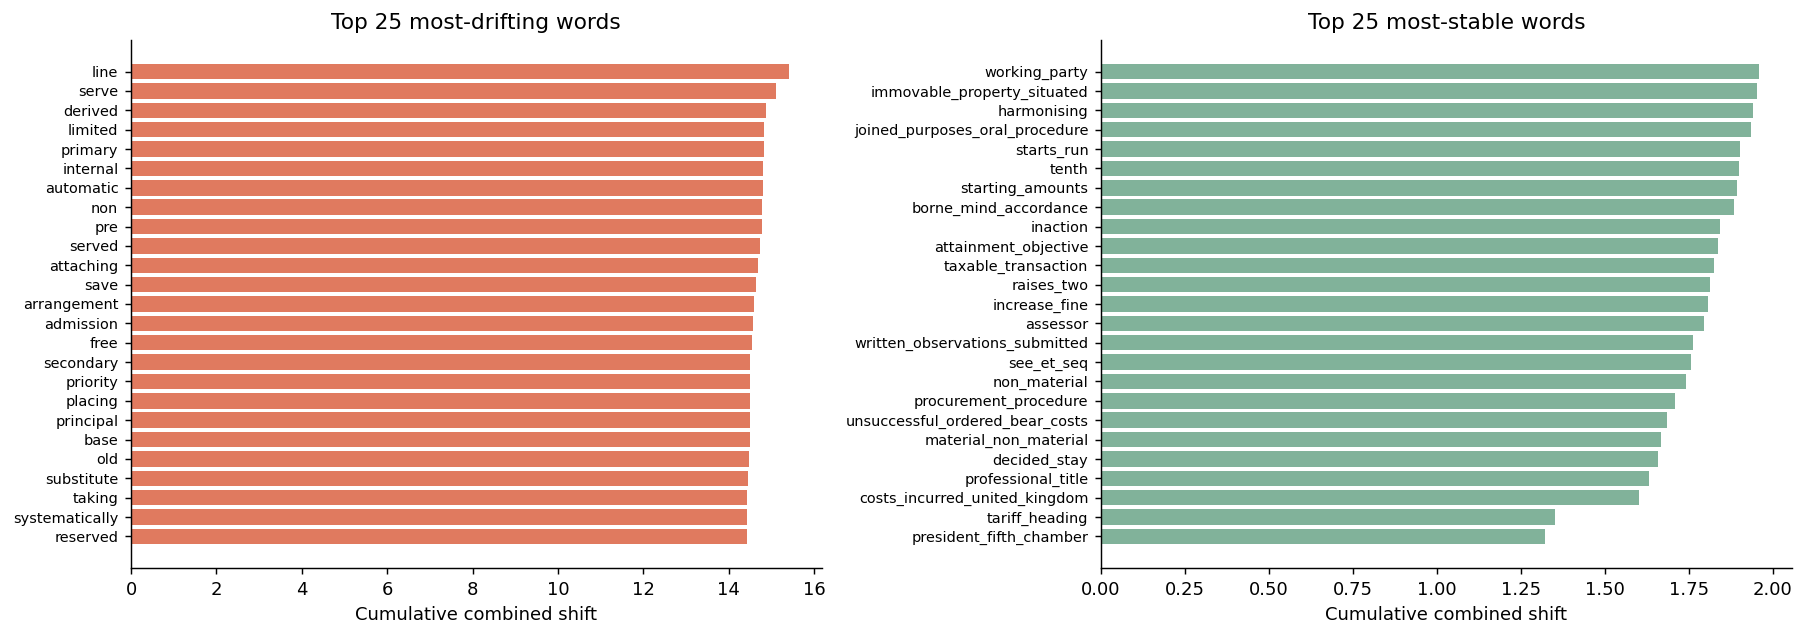

In [2]:
# Cumulative combined shift per word
cum_shift = shifts.groupby("word")["combined_shift"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 25 drifters
top = cum_shift.head(25)
axes[0].barh(range(len(top)), top.values, color="#e07a5f")
axes[0].set_yticks(range(len(top)))
axes[0].set_yticklabels(top.index, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlabel("Cumulative combined shift")
axes[0].set_title("Top 25 most-drifting words")

# Bottom 25 (most stable)
bottom = cum_shift.tail(25)
axes[1].barh(range(len(bottom)), bottom.values, color="#81b29a")
axes[1].set_yticks(range(len(bottom)))
axes[1].set_yticklabels(bottom.index, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_xlabel("Cumulative combined shift")
axes[1].set_title("Top 25 most-stable words")

fig.tight_layout()
plt.show()

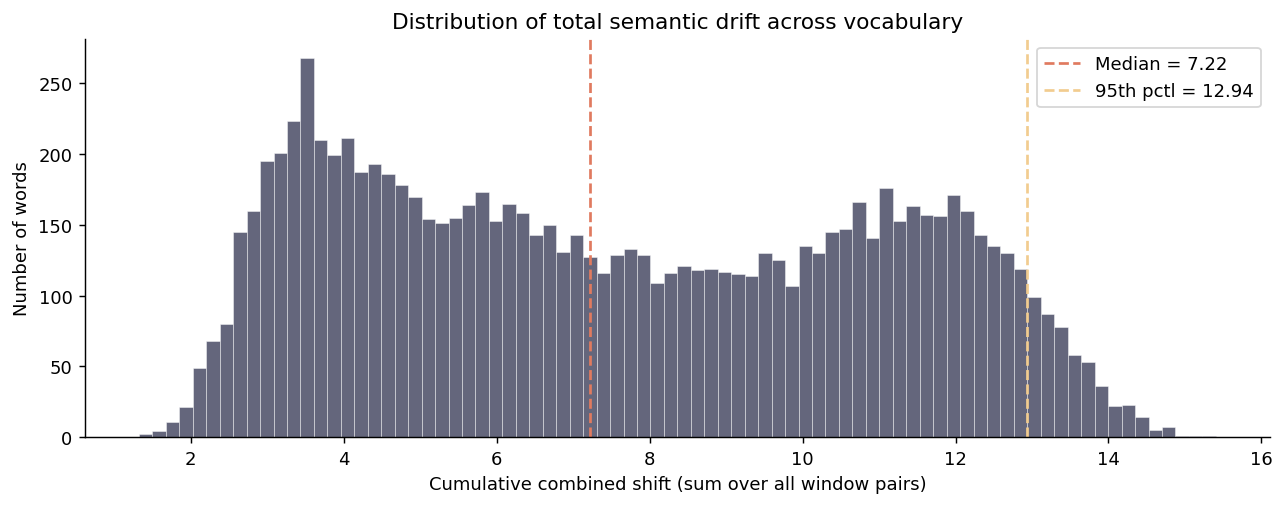

In [3]:
# Distribution of cumulative drift
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(cum_shift.values, bins=80, color="#3d405b", alpha=0.8, edgecolor="white", linewidth=0.3)
ax.axvline(cum_shift.median(), color="#e07a5f", ls="--", label=f"Median = {cum_shift.median():.2f}")
ax.axvline(cum_shift.quantile(0.95), color="#f2cc8f", ls="--", label=f"95th pctl = {cum_shift.quantile(0.95):.2f}")
ax.set_xlabel("Cumulative combined shift (sum over all window pairs)")
ax.set_ylabel("Number of words")
ax.set_title("Distribution of total semantic drift across vocabulary")
ax.legend()
fig.tight_layout()
plt.show()

---
## 2. Drift trajectories for key legal concepts

Tracking cumulative cosine shift and Jaccard neighborhood shift for hand-picked terms of legal interest.

In [4]:
LEGAL_TERMS = [
    "data", "privacy", "digital", "surveillance",
    "climate", "sustainable", "environment",
    "fundamental", "charter", "discrimination",
    "competition", "merger", "subsidy",
    "asylum", "refugee", "migration", "terrorism",
    "proportionality", "regulation", "directive",
    "consumer", "market", "protection",
]
# Keep only those present in the data
present = [w for w in LEGAL_TERMS if w in shifts["word"].values]
print(f"Plotting {len(present)} / {len(LEGAL_TERMS)} terms")

Plotting 23 / 23 terms


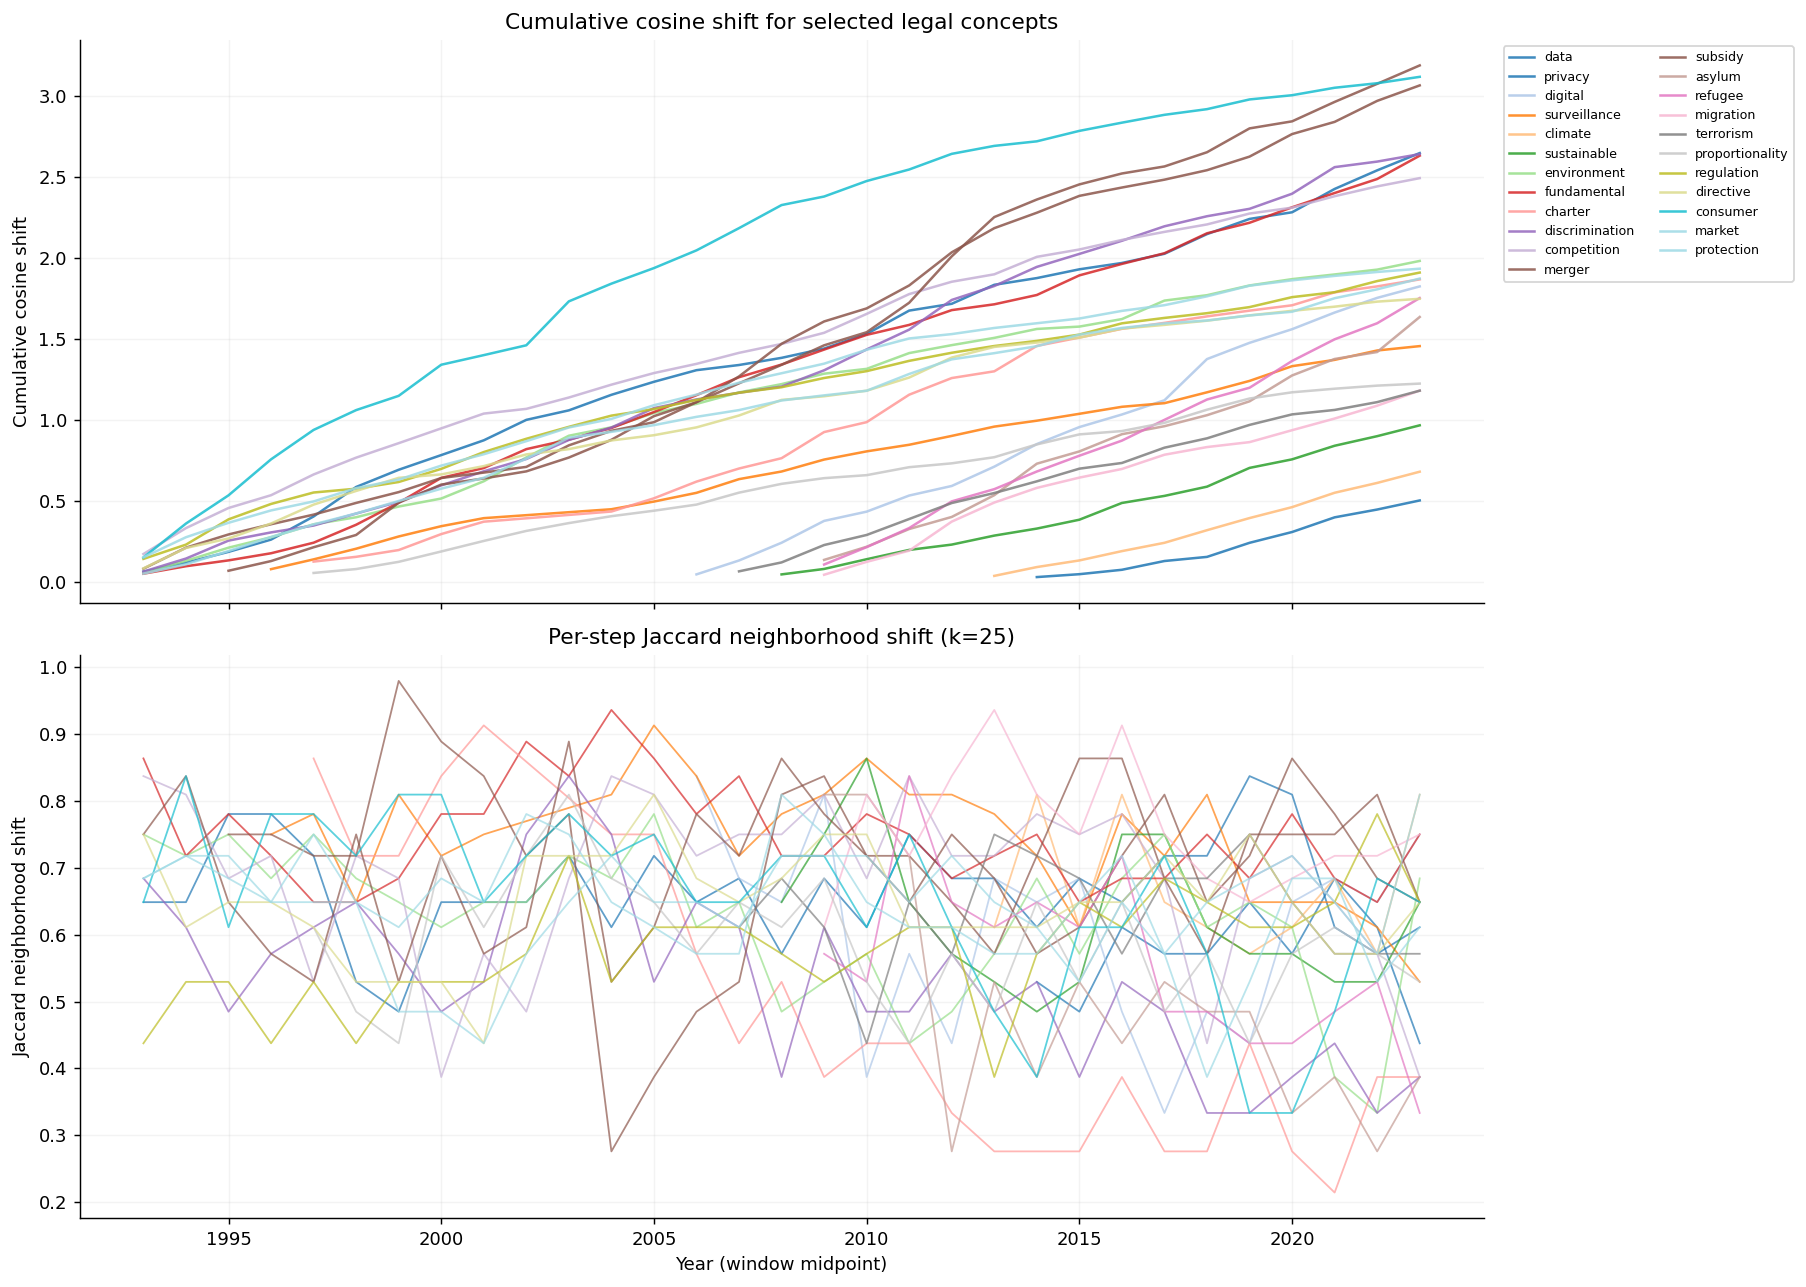

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
colors = dict(zip(present, cm.tab20(np.linspace(0, 1, len(present)))))

for word in present:
    wdf = shifts[shifts["word"] == word].copy()
    wdf["mid"] = wdf["t2"].apply(window_midpoint)
    wdf = wdf.sort_values("mid")

    # Cumulative cosine shift
    axes[0].plot(wdf["mid"], wdf["cosine_shift"].cumsum(),
                 label=word, color=colors[word], linewidth=1.4, alpha=0.85)

    # Per-step Jaccard shift
    axes[1].plot(wdf["mid"], wdf["jaccard_shift"],
                 label=word, color=colors[word], linewidth=1.0, alpha=0.7)

axes[0].set_ylabel("Cumulative cosine shift")
axes[0].set_title("Cumulative cosine shift for selected legal concepts")
axes[0].legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7, ncol=2)
axes[0].grid(True, alpha=0.15)

axes[1].set_ylabel("Jaccard neighborhood shift")
axes[1].set_xlabel("Year (window midpoint)")
axes[1].set_title("Per-step Jaccard neighborhood shift (k=25)")
axes[1].grid(True, alpha=0.15)

fig.tight_layout()
plt.show()

---
## 3. Cosine shift vs. Jaccard shift

Do the two metrics agree? Words in the upper-right corner moved in vector space *and* changed their nearest neighbors. Words on the axes moved on only one dimension.

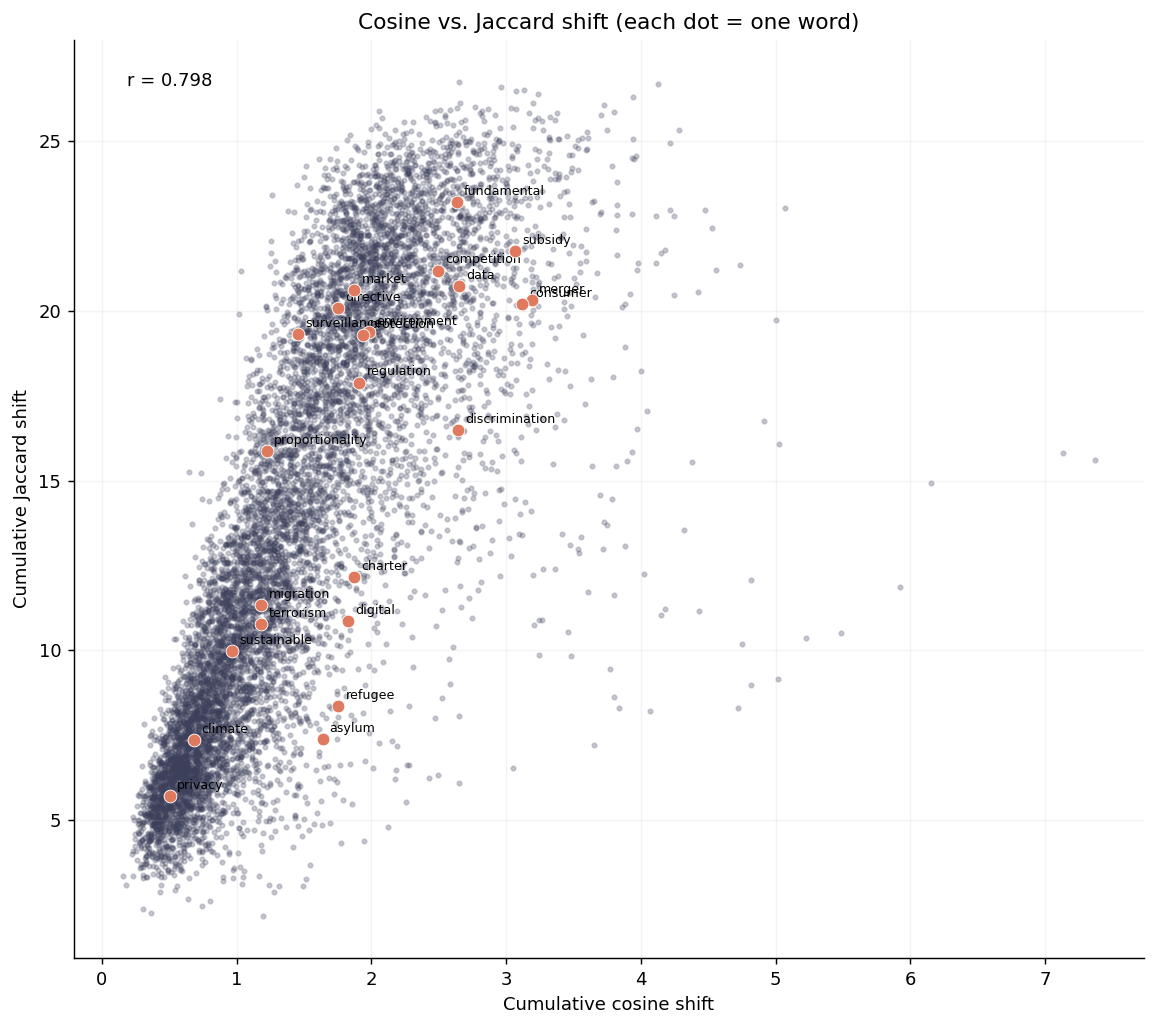

In [6]:
cum = shifts.groupby("word").agg(
    cosine=("cosine_shift", "sum"),
    jaccard=("jaccard_shift", "sum"),
).reset_index()

fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(cum["cosine"], cum["jaccard"], s=6, alpha=0.25, color="#3d405b")

# Highlight legal terms
for word in present:
    row = cum[cum["word"] == word]
    if row.empty:
        continue
    ax.scatter(row["cosine"], row["jaccard"], s=50, color="#e07a5f", zorder=5, edgecolors="white", linewidths=0.5)
    ax.annotate(word, (row["cosine"].values[0], row["jaccard"].values[0]),
                fontsize=7, xytext=(4, 4), textcoords="offset points")

ax.set_xlabel("Cumulative cosine shift")
ax.set_ylabel("Cumulative Jaccard shift")
ax.set_title("Cosine vs. Jaccard shift (each dot = one word)")
r = cum["cosine"].corr(cum["jaccard"])
ax.annotate(f"r = {r:.3f}", xy=(0.05, 0.95), xycoords="axes fraction", fontsize=10)
ax.grid(True, alpha=0.15)
fig.tight_layout()
plt.show()

---
## 4. Domain coherence over time

How tightly clustered are words within predefined legal domains? Declining coherence suggests a domain's vocabulary is dispersing into broader usage; rising coherence suggests specialisation.

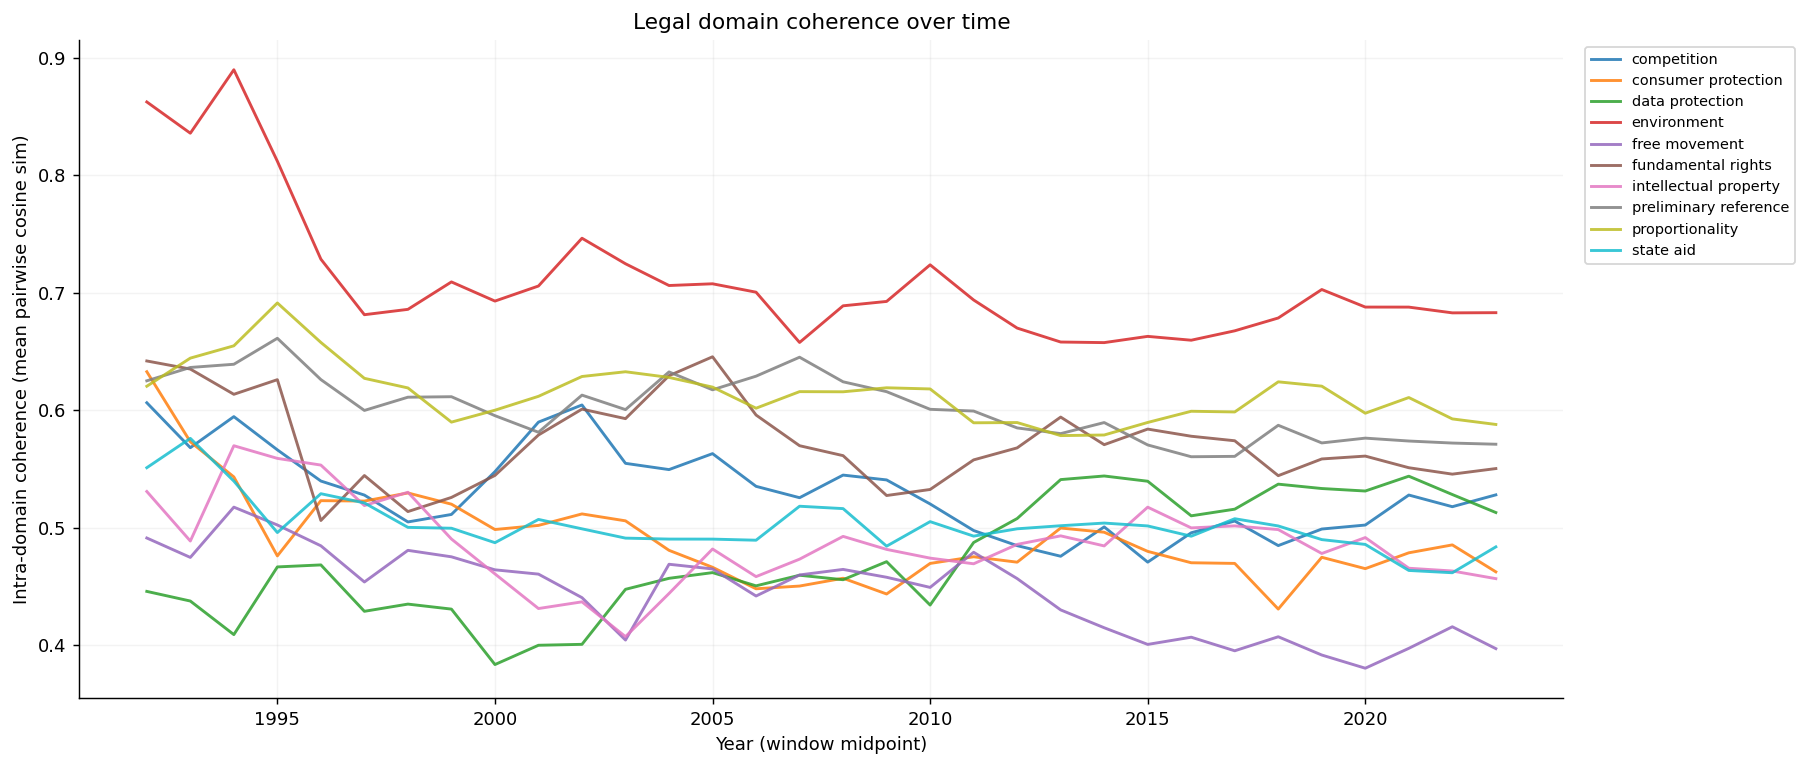

In [7]:
coherence["mid"] = coherence["time_slice"].apply(window_midpoint)
domains = sorted(coherence["domain"].unique())

fig, ax = plt.subplots(figsize=(14, 6))
domain_colors = dict(zip(domains, cm.tab10(np.linspace(0, 1, len(domains)))))

for domain in domains:
    ddf = coherence[coherence["domain"] == domain].sort_values("mid")
    ax.plot(ddf["mid"], ddf["coherence"], label=domain.replace("_", " "),
            color=domain_colors[domain], linewidth=1.6, alpha=0.85)

ax.set_xlabel("Year (window midpoint)")
ax.set_ylabel("Intra-domain coherence (mean pairwise cosine sim)")
ax.set_title("Legal domain coherence over time")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.grid(True, alpha=0.15)
fig.tight_layout()
plt.show()

---
## 5. Semantic dispersion: broadening vs. narrowing

k-NN dispersion measures how far a word is from its 25 nearest neighbors. Rising dispersion = the word is used in more diverse contexts (semantic broadening). Falling = specialisation.

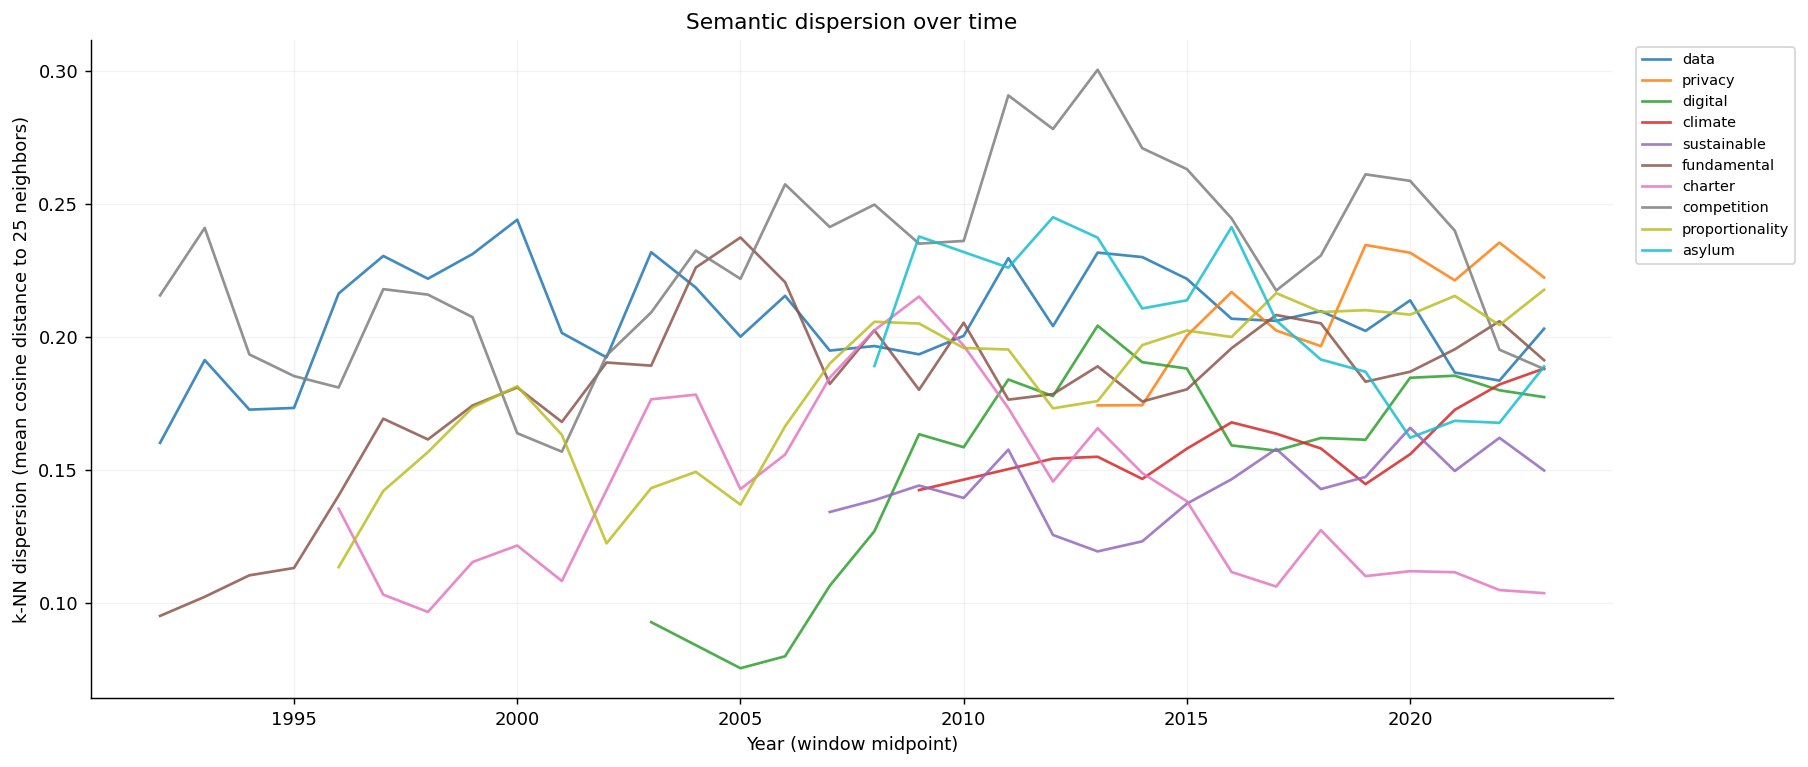

In [8]:
# Pick a focused subset: terms where we expect broadening/narrowing
focus_terms = ["data", "privacy", "digital", "climate", "sustainable",
               "fundamental", "charter", "competition", "proportionality", "asylum"]
focus_present = [w for w in focus_terms if w in dispersion["word"].values]

disp_sub = dispersion[dispersion["word"].isin(focus_present)].copy()
disp_sub = disp_sub.dropna(subset=["dispersion"])
disp_sub["mid"] = disp_sub["time_slice"].apply(window_midpoint)

fig, ax = plt.subplots(figsize=(14, 6))
colors_f = dict(zip(focus_present, cm.tab10(np.linspace(0, 1, len(focus_present)))))

for word in focus_present:
    wdf = disp_sub[disp_sub["word"] == word].sort_values("mid")
    ax.plot(wdf["mid"], wdf["dispersion"], label=word,
            color=colors_f[word], linewidth=1.5, alpha=0.85)

ax.set_xlabel("Year (window midpoint)")
ax.set_ylabel("k-NN dispersion (mean cosine distance to 25 neighbors)")
ax.set_title("Semantic dispersion over time")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.grid(True, alpha=0.15)
fig.tight_layout()
plt.show()

---
## 6. Heatmap: per-step shift intensity across time

Each cell shows the mean cosine shift for a given word at a given time step. Darker = more change in that period.

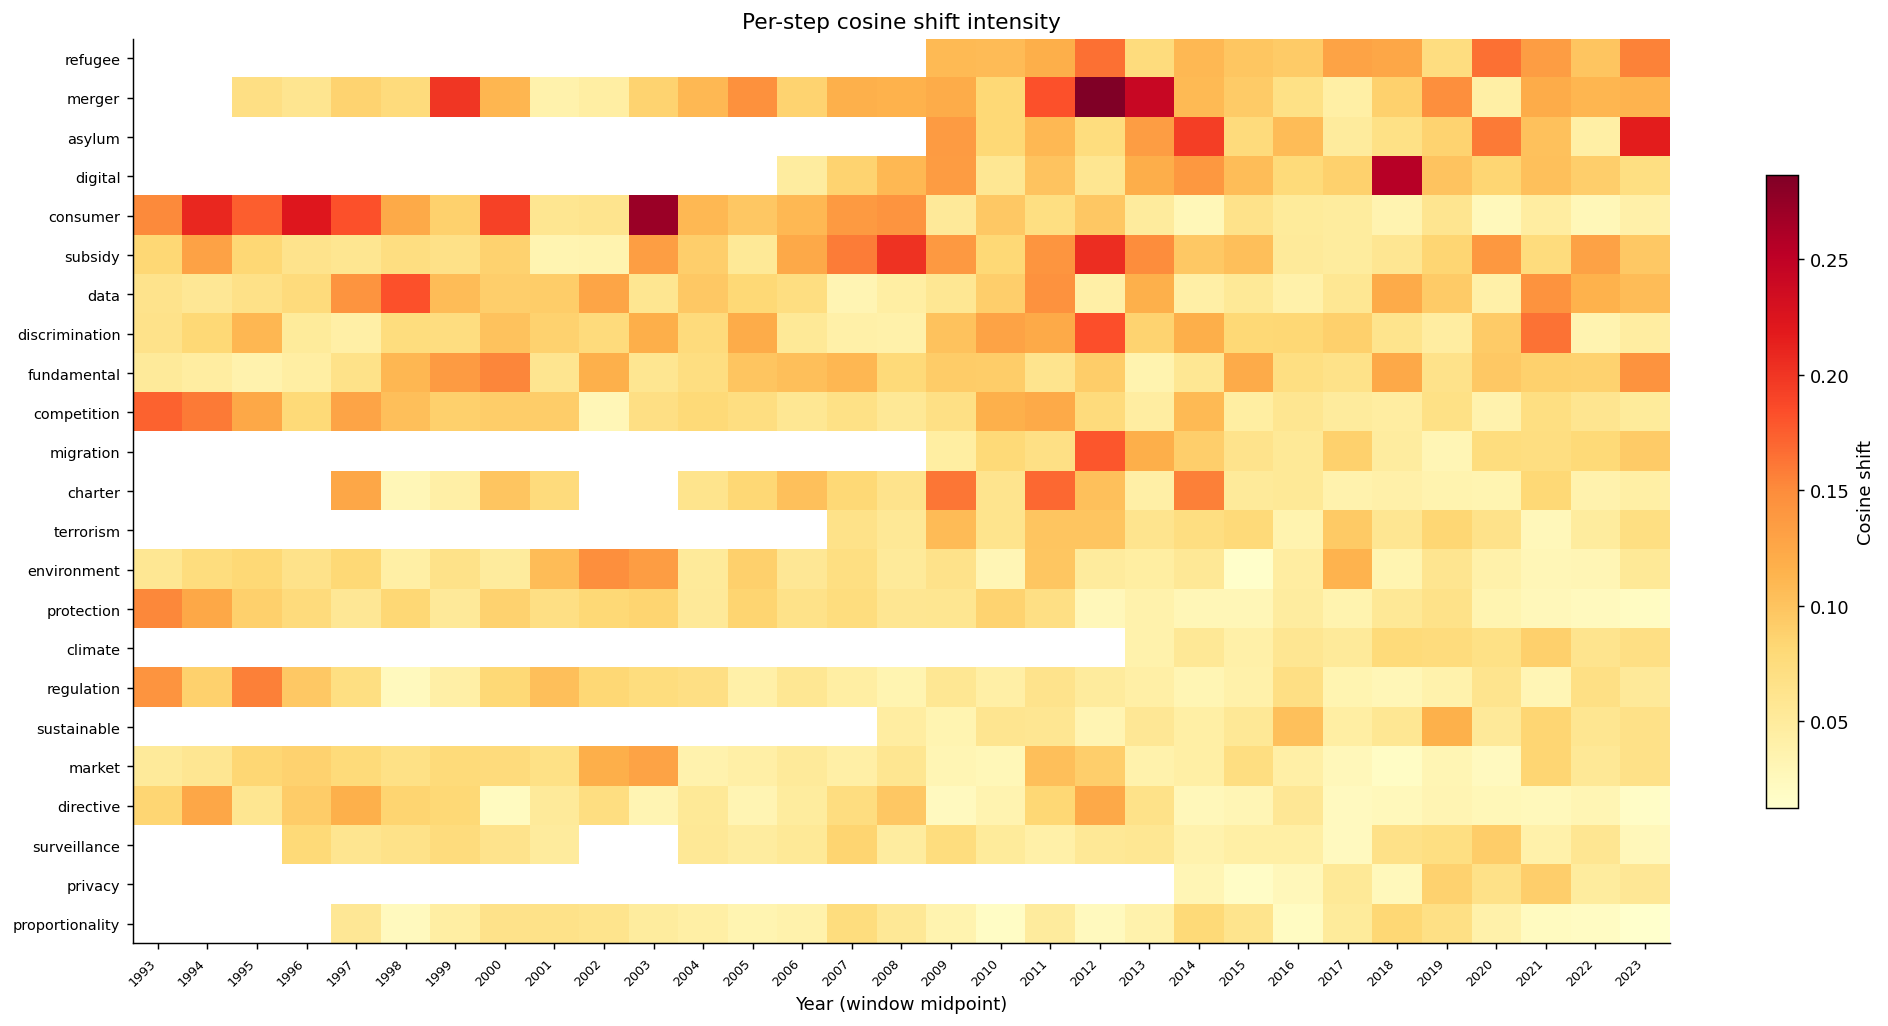

In [9]:
heatmap_words = present  # the legal terms defined earlier

heat = shifts[shifts["word"].isin(heatmap_words)].copy()
heat["mid"] = heat["t2"].apply(window_midpoint)
pivot = heat.pivot_table(index="word", columns="mid", values="cosine_shift")
pivot = pivot.reindex(
    pivot.mean(axis=1).sort_values(ascending=False).index
)

fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd", interpolation="nearest")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=8)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{int(c)}" for c in pivot.columns], fontsize=7, rotation=45, ha="right")
ax.set_xlabel("Year (window midpoint)")
ax.set_title("Per-step cosine shift intensity")
fig.colorbar(im, ax=ax, label="Cosine shift", shrink=0.7)
fig.tight_layout()
plt.show()

---
## 7. PCA trajectories

Word positions projected to 2D (PCA on stacked aligned embeddings). Lines connect the same word across time slices; lighter points are earlier, darker points are later.

In [10]:
from src.embeddings.alignment import load_aligned
from src.visualization.embedding_plots import stack_embeddings, reduce_pca, plot_trajectories

aligned_kvs = load_aligned("../data/models/aligned")

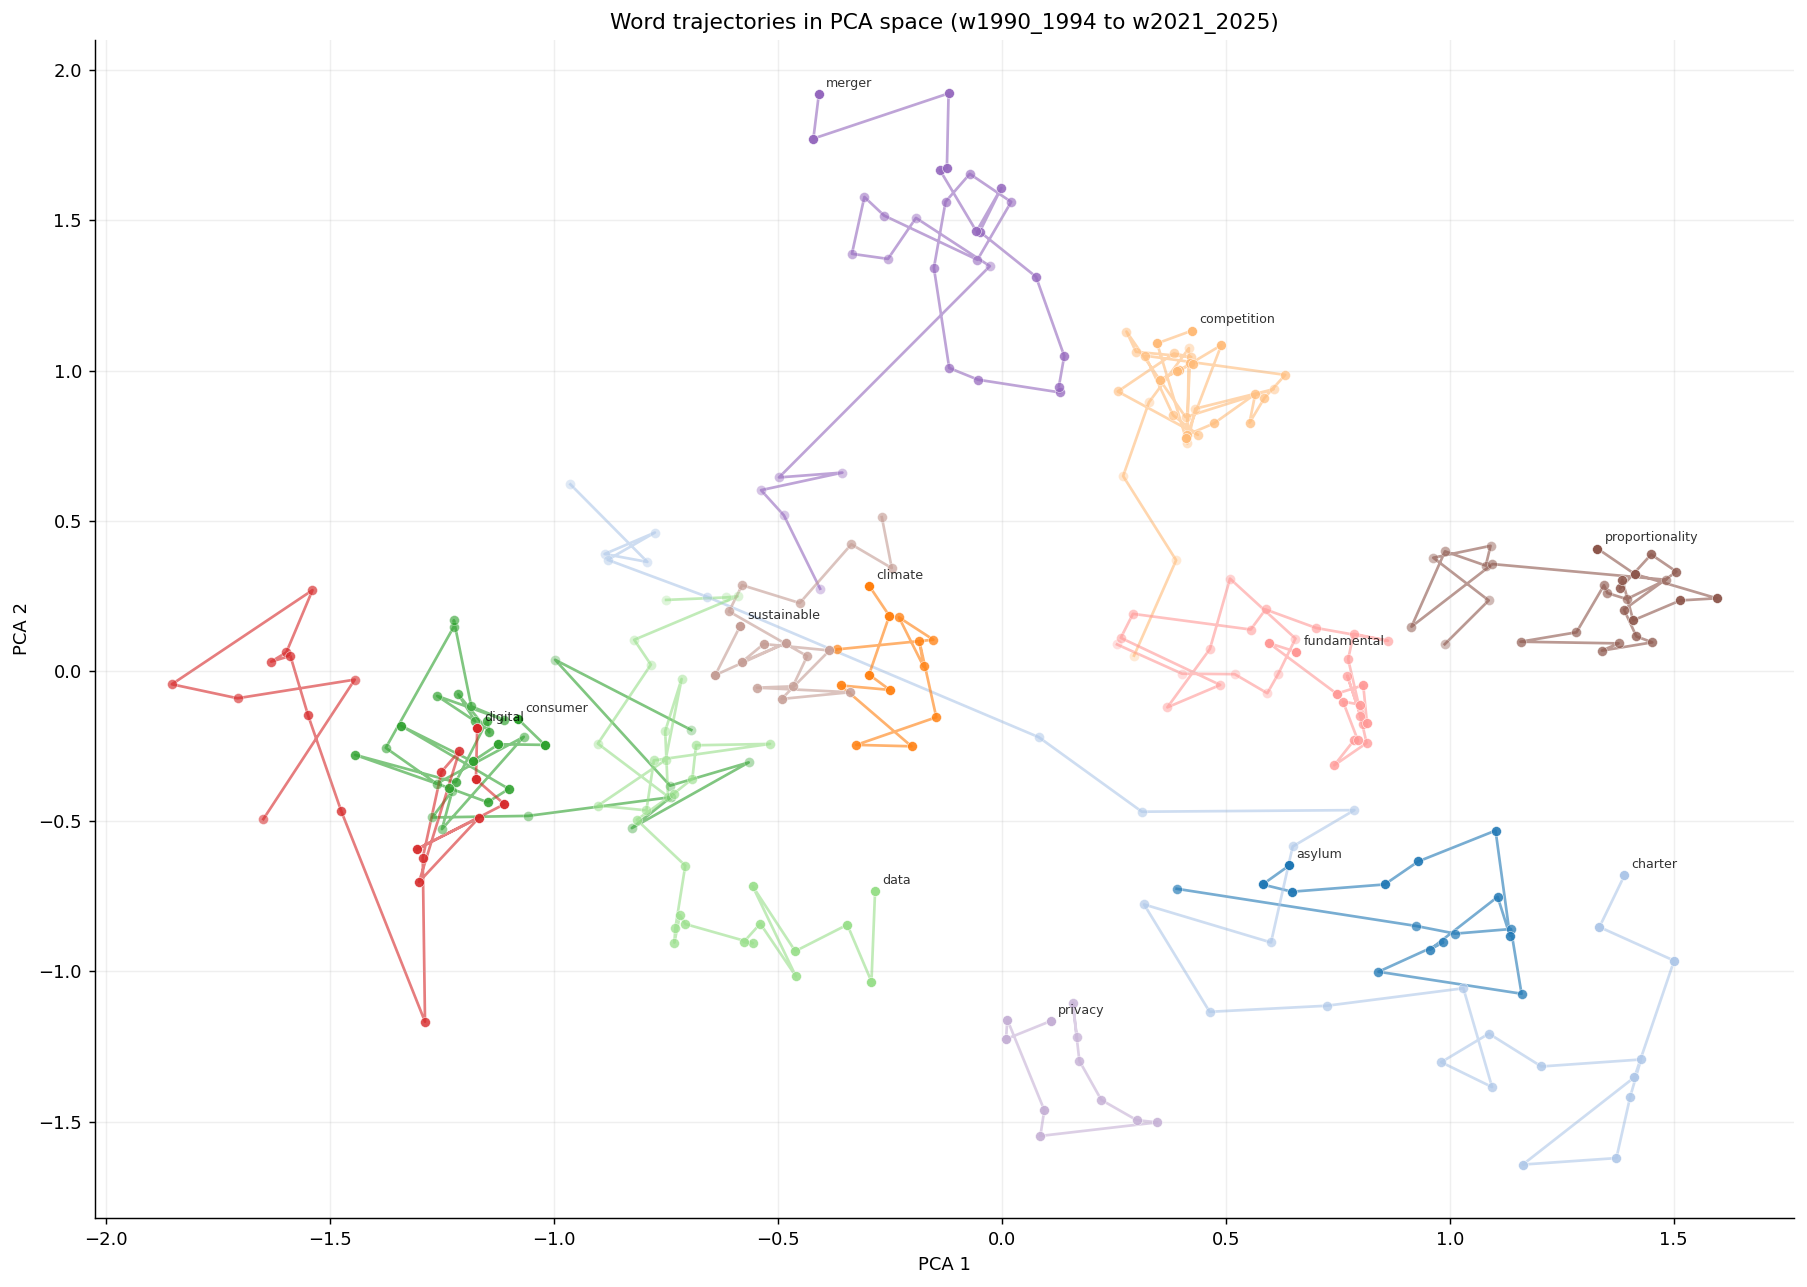

In [11]:
# Trajectory plot for legal terms
trajectory_words = ["data", "privacy", "digital", "climate", "fundamental",
                    "charter", "competition", "asylum", "proportionality",
                    "consumer", "sustainable", "merger"]
trajectory_present = [w for w in trajectory_words if any(w in kv for kv in aligned_kvs.values())]

matrix, word_labels, time_labels = stack_embeddings(aligned_kvs, trajectory_present)
coords = reduce_pca(matrix)

fig = plot_trajectories(
    coords, word_labels, time_labels,
    words_to_plot=trajectory_present,
    method="PCA",
    figsize=(14, 10),
)
plt.show()

---
## 8. Neighborhood snapshots

What are the nearest neighbors of key terms at the start vs. end of the study period? This gives qualitative evidence for *how* meaning shifted.

In [12]:
labels = sorted(aligned_kvs.keys())

snapshot_words = ["data", "fundamental", "climate", "competition",
                  "proportionality", "digital", "charter", "asylum"]

for word in snapshot_words:
    # Find earliest and latest window where the word exists
    word_labels = [l for l in labels if word in aligned_kvs[l]]
    if len(word_labels) < 2:
        print(f"\n--- {word.upper()} --- (present in {len(word_labels)} window(s), skipping)")
        continue

    el, ll = word_labels[0], word_labels[-1]
    early_nn = aligned_kvs[el].most_similar(word, topn=10)
    late_nn  = aligned_kvs[ll].most_similar(word, topn=10)

    rows = []
    for rank, ((ew, es), (lw, ls)) in enumerate(zip(early_nn, late_nn), 1):
        rows.append({
            "rank": rank,
            f"neighbor ({el})": ew, f"sim": f"{es:.3f}",
            f"neighbor ({ll})": lw, f"sim ": f"{ls:.3f}",
        })
    print(f"\n--- {word.upper()} --- (earliest: {el}, latest: {ll})")
    print(pd.DataFrame(rows).to_string(index=False))


--- DATA --- (earliest: w1990_1994, latest: w2021_2025)
 rank neighbor (w1990_1994)   sim   neighbor (w2021_2025)  sim 
    1            statistics 0.966          data_collected 0.900
    2           statistical 0.890 personal_data_collected 0.843
    3               figures 0.889        fair_transparent 0.839
    4             exchanged 0.888         processing_data 0.830
    5       exchange_system 0.881                database 0.817
    6                source 0.859               collected 0.816
    7           combination 0.852               profiling 0.815
    8                  show 0.842 personal_data_processed 0.813
    9               samples 0.842           personal_data 0.810
   10              accuracy 0.841               anonymous 0.810

--- FUNDAMENTAL --- (earliest: w1990_1994, latest: w2021_2025)
 rank neighbor (w1990_1994)   sim     neighbor (w2021_2025)  sim 
    1                remove 0.926    european_union_founded 0.836
    2       legal_certainty 0.922         s

---
## 9. Aggregate drift tempo

Is drift accelerating or decelerating? Mean cosine shift across all words at each time step.

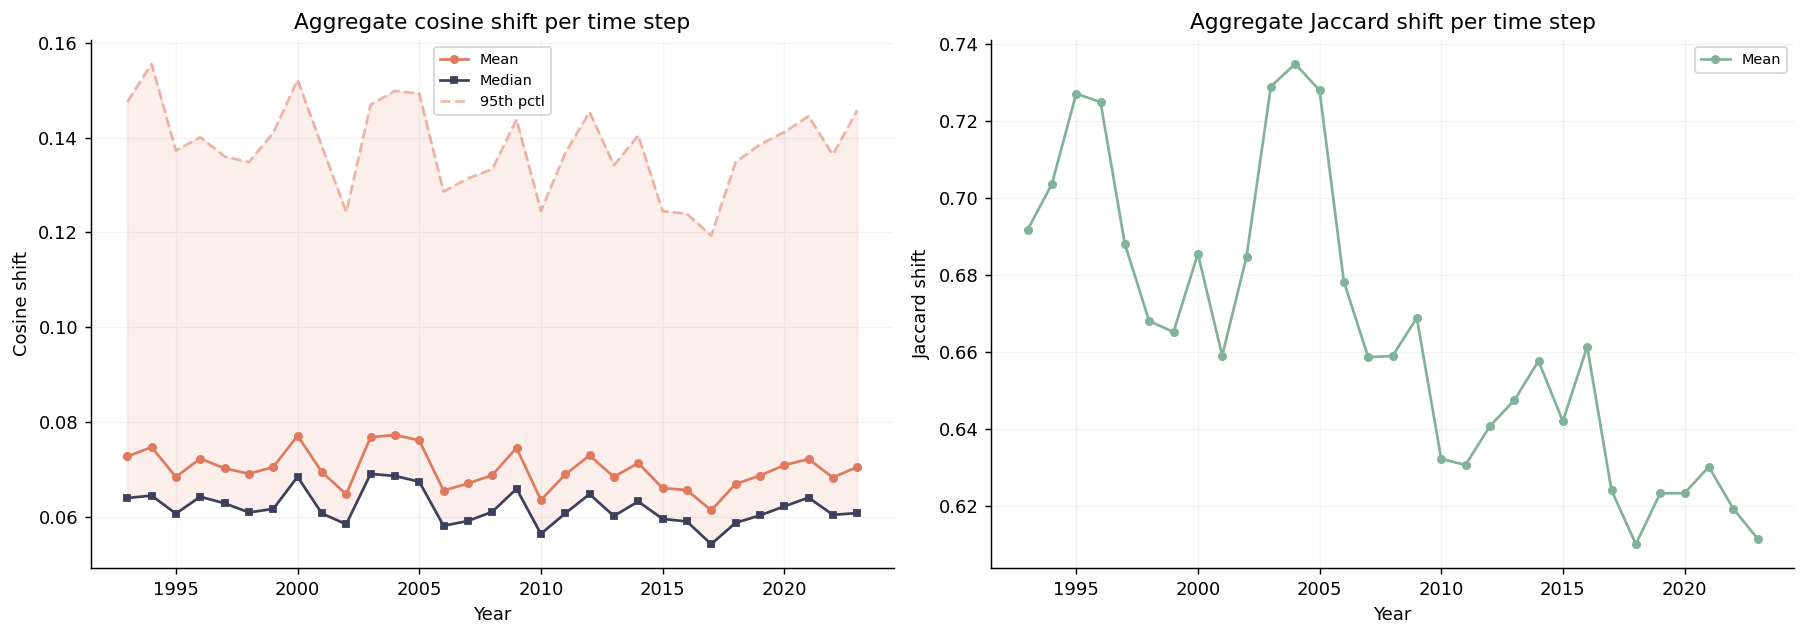

In [13]:
tempo = shifts.copy()
tempo["mid"] = tempo["t2"].apply(window_midpoint)

agg = tempo.groupby("mid").agg(
    mean_cosine=("cosine_shift", "mean"),
    median_cosine=("cosine_shift", "median"),
    p95_cosine=("cosine_shift", lambda x: x.quantile(0.95)),
    mean_jaccard=("jaccard_shift", "mean"),
).reset_index().sort_values("mid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cosine
axes[0].plot(agg["mid"], agg["mean_cosine"], "o-", color="#e07a5f", label="Mean", markersize=4)
axes[0].plot(agg["mid"], agg["median_cosine"], "s-", color="#3d405b", label="Median", markersize=3)
axes[0].fill_between(agg["mid"], agg["median_cosine"], agg["p95_cosine"], alpha=0.12, color="#e07a5f")
axes[0].plot(agg["mid"], agg["p95_cosine"], "--", color="#e07a5f", alpha=0.5, label="95th pctl")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Cosine shift")
axes[0].set_title("Aggregate cosine shift per time step")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.15)

# Jaccard
axes[1].plot(agg["mid"], agg["mean_jaccard"], "o-", color="#81b29a", label="Mean", markersize=4)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Jaccard shift")
axes[1].set_title("Aggregate Jaccard shift per time step")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.15)

fig.tight_layout()
plt.show()

---
## 10. Summary table: legal terms ranked by drift

A sortable overview of drift metrics for all tracked legal terms.

In [14]:
legal_shifts = shifts[shifts["word"].isin(present)]
legal_disp = dispersion[dispersion["word"].isin(present)].dropna(subset=["dispersion"])

summary = (
    legal_shifts.groupby("word")
    .agg(
        cum_cosine=("cosine_shift", "sum"),
        cum_jaccard=("jaccard_shift", "sum"),
        cum_combined=("combined_shift", "sum"),
        max_cosine_step=("cosine_shift", "max"),
        n_pairs=("cosine_shift", "count"),
    )
    .reset_index()
)

# Add dispersion trend (slope of linear fit)
from numpy.polynomial.polynomial import polyfit
disp_slopes = {}
for word in present:
    wdf = legal_disp[legal_disp["word"] == word].copy()
    wdf["mid"] = wdf["time_slice"].apply(window_midpoint)
    wdf = wdf.sort_values("mid")
    if len(wdf) >= 5:
        c = polyfit(wdf["mid"], wdf["dispersion"], 1)
        disp_slopes[word] = c[1]  # slope
    else:
        disp_slopes[word] = np.nan

summary["disp_trend"] = summary["word"].map(disp_slopes)

# Global rank
all_cum = shifts.groupby("word")["combined_shift"].sum()
summary["rank"] = summary["word"].map(lambda w: int((all_cum >= all_cum.get(w, 0)).sum()))
summary["pctl"] = summary["word"].map(lambda w: 100 * (all_cum < all_cum.get(w, 0)).mean())

summary = summary.sort_values("cum_combined", ascending=False)
summary = summary.round(3)

display_cols = ["word", "rank", "pctl", "cum_cosine", "cum_jaccard", "cum_combined",
                "max_cosine_step", "disp_trend", "n_pairs"]
summary[display_cols].style.format({
    "pctl": "{:.1f}%", "disp_trend": "{:.5f}"
}).background_gradient(subset=["cum_combined"], cmap="YlOrRd")

,word,rank,pctl,cum_cosine,cum_jaccard,cum_combined,max_cosine_step,disp_trend,n_pairs
10,fundamental,505,94.8%,2.634000,23.199000,12.917000,0.154000,0.00200,31
19,subsidy,871,91.1%,3.068000,21.754000,12.411000,0.205000,0.00300,31
3,competition,1382,85.8%,2.495000,21.182000,11.838000,0.173000,0.00200,31
12,merger,1456,85.0%,3.192000,20.318000,11.755000,0.287000,0.00400,29
5,data,1523,84.4%,2.650000,20.722000,11.686000,0.182000,0.00000,31
4,consumer,1553,84.1%,3.121000,20.183000,11.652000,0.271000,-0.00000,31
11,market,1917,80.3%,1.875000,20.602000,11.239000,0.129000,-0.00100,31
7,directive,2215,77.3%,1.750000,20.074000,10.912000,0.126000,-0.00100,31
9,environment,2426,75.1%,1.984000,19.381000,10.682000,0.147000,0.00100,31
16,protection,2507,74.3%,1.936000,19.275000,10.605000,0.152000,0.00000,31
